# 05 — Model Interpretability (SHAP)

The models in `04_modeling.ipynb` predict *whether* someone is at risk. This
notebook explains *why* — which features drive the best model's predictions,
both globally (across the whole population) and for individual predictions.
This is what turns the project from a black-box classifier into something a
domain reader can actually trust and act on.

Structure:
1. Load the best model and test data
2. Compute SHAP values
3. Global feature importance (summary + bar plots)
4. Individual prediction explanations (waterfall plots)
5. Compare SHAP ranking against notebook 02's statistical ranking
6. Interpretation

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, set_seed, resolve_path
from src.train import load_model
from src.interpret import (
    compute_shap_values, plot_shap_summary, plot_shap_bar,
    plot_shap_waterfall, get_top_features_by_shap, find_extreme_predictions,
)

config = load_config()
set_seed(config["random_seed"])
FIG_DIR = resolve_path(config["paths"]["figures_dir"])
MODELS_DIR = resolve_path(config["paths"]["models_dir"])

## 1. Load Best Model and Test Data

In [2]:
with open(MODELS_DIR / "model_metadata.json") as f:
    metadata = json.load(f)

best_model_name = metadata["best_model_name"]
print(f"Explaining: {best_model_name}")

model = load_model(str(MODELS_DIR / "best_model.joblib"))

processed_dir = resolve_path("data/processed")
X_test = pd.read_parquet(processed_dir / "X_test.parquet")
y_test = pd.read_parquet(processed_dir / "y_test.parquet").iloc[:, 0]

# SHAP on the full test set can be slow for tree models on 253k-scale data;
# sample for a fast, still-representative explanation. Increase if you have
# time/compute budget for a more precise global picture.
SHAP_SAMPLE_SIZE = 2000
X_shap = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=config["random_seed"])
print(f"Using {len(X_shap)} test rows for SHAP computation.")

Explaining: XGBoost
Using 2000 test rows for SHAP computation.


## 2. Compute SHAP Values

Using TreeExplainer for tree-based models (Random Forest/XGBoost — fast and
exact) or LinearExplainer for Logistic Regression, matching whichever model
notebook 04 actually selected.

In [3]:
tree_model_names = {"Random Forest", "XGBoost"}
model_type = "tree" if best_model_name in tree_model_names else "linear"
print(f"Using SHAP {model_type} explainer for {best_model_name}")

shap_values = compute_shap_values(model, X_shap, model_type=model_type)

Using SHAP tree explainer for XGBoost


c:\Users\Huawei\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Global Feature Importance

The beeswarm plot shows both *how much* each feature matters and *which
direction* it pushes predictions (e.g. does high BMI push risk up or down,
and by how much, across all individuals) — richer than a plain importance
ranking.

c:\diabetes-risk-prediction\src\interpret.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, max_display=max_display, show=False)


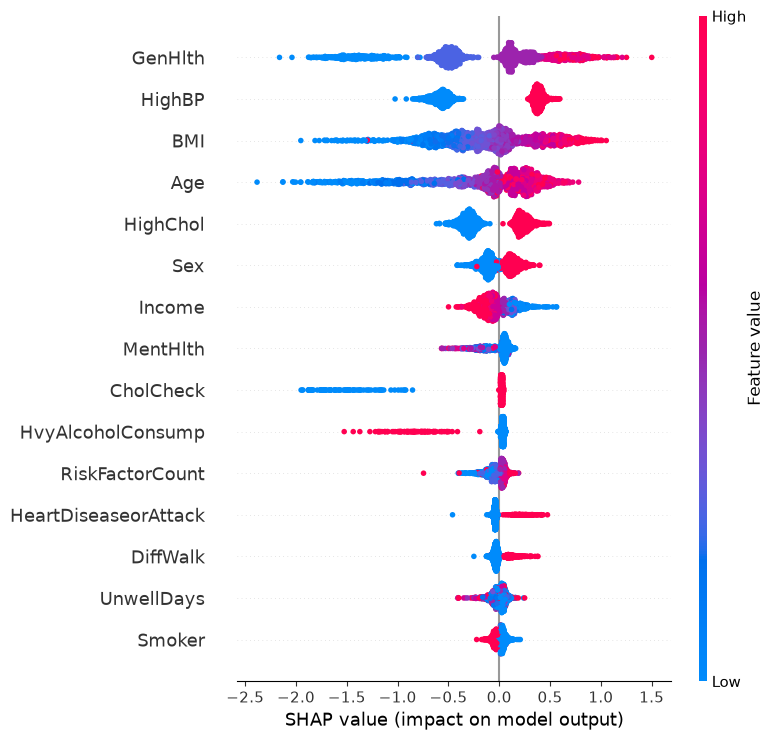

In [4]:
plot_shap_summary(shap_values, X_shap, save_path=str(FIG_DIR / "15_shap_summary_beeswarm.png"))
plt.show()

c:\diabetes-risk-prediction\src\interpret.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar", max_display=max_display, show=False)


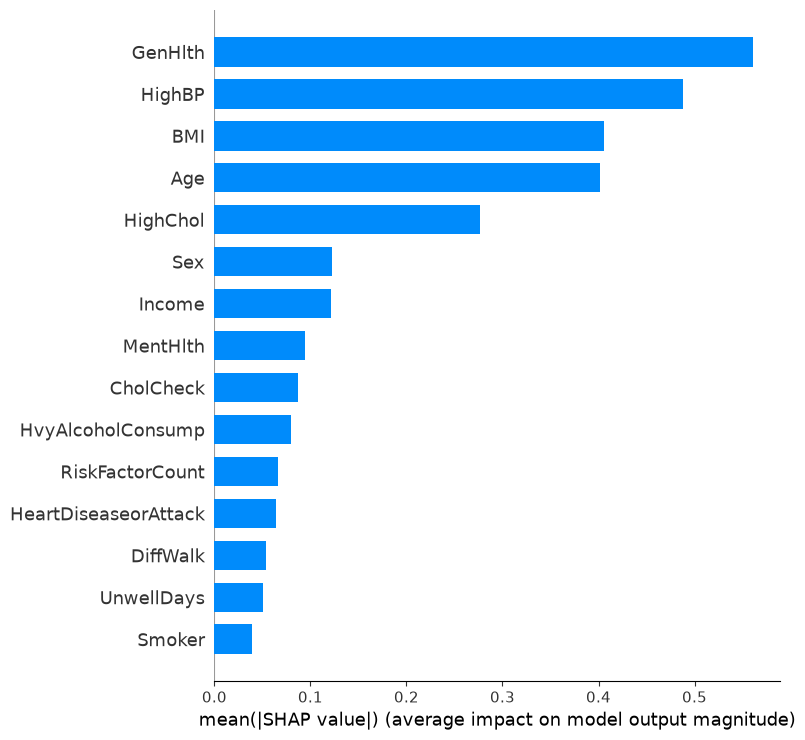

In [5]:
plot_shap_bar(shap_values, X_shap, save_path=str(FIG_DIR / "16_shap_bar_importance.png"))
plt.show()

In [6]:
top_features = get_top_features_by_shap(shap_values, X_shap, n=10)
top_features

,feature,mean_abs_shap
0,GenHlth,0.560960
1,HighBP,0.488306
2,BMI,0.406234
3,Age,0.401291
4,HighChol,0.276822
5,Sex,0.122303
6,Income,0.121051
7,MentHlth,0.094119
8,CholCheck,0.087102
9,HvyAlcoholConsump,0.079969


## 4. Individual Prediction Explanations

Rather than picking a random row (often unremarkable), explaining the
highest- and lowest-predicted-risk individuals in the sample — these make
the clearest, most interpretable waterfall plots and are the most useful
examples for a stakeholder-facing explanation.

In [7]:
extremes = find_extreme_predictions(model, X_shap, n=2)
print("Highest-risk row indices (within X_shap):", extremes["highest_risk_idx"])
print("Lowest-risk row indices (within X_shap):", extremes["lowest_risk_idx"])

Highest-risk row indices (within X_shap): [1746, 1231]
Lowest-risk row indices (within X_shap): [1116, 1028]


Highest predicted risk — what's driving it up:


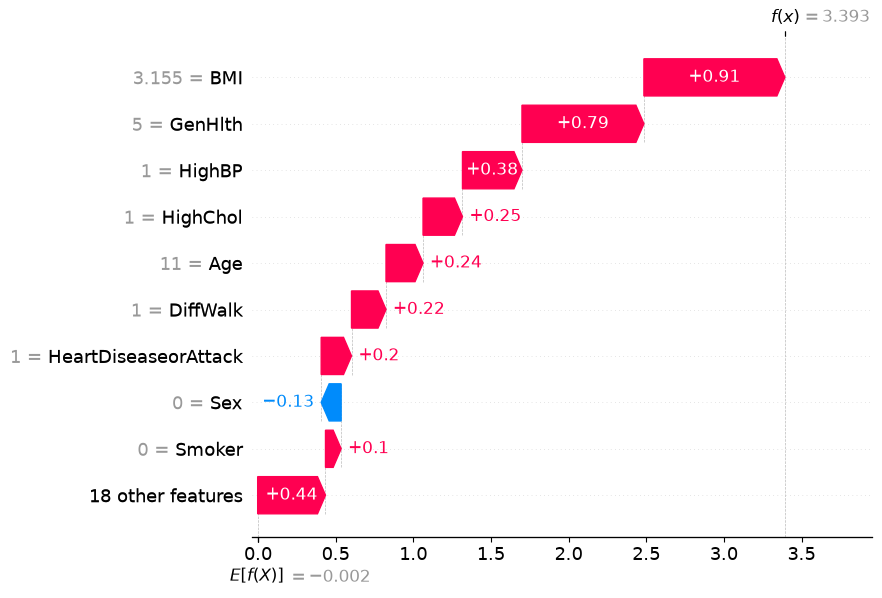

In [8]:
print("Highest predicted risk — what's driving it up:")
plot_shap_waterfall(shap_values, extremes["highest_risk_idx"][0], save_path=str(FIG_DIR / "17_shap_waterfall_highest_risk.png"))
plt.show()

Lowest predicted risk — what's keeping it down:


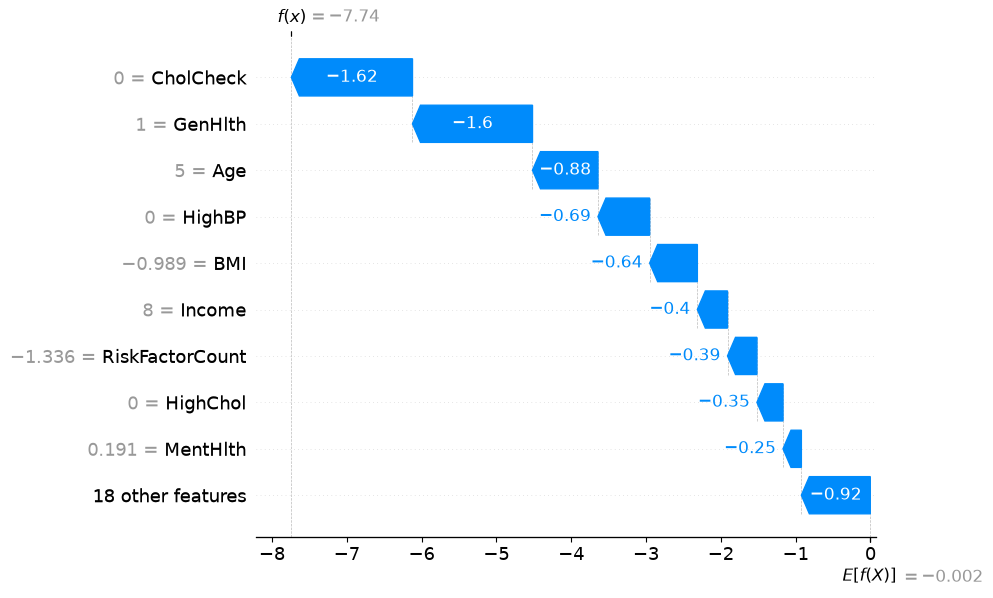

In [9]:
print("Lowest predicted risk — what's keeping it down:")
plot_shap_waterfall(shap_values, extremes["lowest_risk_idx"][0], save_path=str(FIG_DIR / "18_shap_waterfall_lowest_risk.png"))
plt.show()

## 5. SHAP Ranking vs. Notebook 02's Statistical Ranking

Notebook 02 ranked features by their *individual* association with the
target (point-biserial / Cramer's V, one feature at a time). SHAP ranks
features by their contribution *inside the model*, accounting for
interactions between features. These can disagree — a feature can be a
strong solo predictor but redundant once other features are present in the
model (or vice versa). Comparing both tells a more complete story than either
alone.

In [10]:
stats_results_path = Path("../reports/statistical_test_results.csv")
if stats_results_path.exists():
    stats_results = pd.read_csv(stats_results_path)
    comparison = top_features.merge(
        stats_results[["feature", "effect_size", "effect_size_label"]],
        on="feature", how="left",
    ).rename(columns={"effect_size": "notebook02_effect_size", "effect_size_label": "notebook02_label"})
    # Engineered features (UnwellDays, RiskFactorCount, BMI_category_*) were
    # created in notebook 03, AFTER notebook 02's tests ran — they were
    # never tested there, so they show as NaN here rather than a numeric
    # miss. Label them explicitly instead of leaving a bare NaN.
    comparison["notebook02_label"] = comparison["notebook02_label"].fillna("not tested in notebook 02 (engineered feature)")
    display(comparison)
else:
    print("Run 02_statistical_analysis.ipynb first to enable this comparison.")


,feature,mean_abs_shap,notebook02_effect_size,notebook02_label
0,GenHlth,0.560960,0.299296,medium
1,HighBP,0.488306,0.263110,medium
2,BMI,0.406234,0.376633,medium
3,Age,0.401291,0.186072,small
4,HighChol,0.276822,0.200255,medium
5,Sex,0.122303,0.031356,negligible
6,Income,0.121051,0.166075,small
7,MentHlth,0.094119,0.054551,negligible
8,CholCheck,0.087102,0.064700,negligible
9,HvyAlcoholConsump,0.079969,0.056997,negligible


## 6. Interpretation

_Fill in after reviewing the plots above:_
- _Top 3-5 features driving predictions overall, and the direction of their effect_
- _Any feature that ranks very differently between notebook 02's stats and SHAP
  here — worth a sentence on why (likely interaction/redundancy effects)_
- _What the highest-risk and lowest-risk waterfall examples reveal about how
  the model combines evidence_

Next: `06_risk_segmentation.ipynb` turns these predictions into risk tiers and
checks how they distribute across income/education/healthcare-access
subgroups — the health-equity angle from the README.